# Đồ án: Nhận diện tiền Việt Nam và giải thích hình ảnh trên từng tờ tiền

## Thành viên nhóm

1. MSSV: 24521725  
   Họ và tên: Đoàn Nguyễn Minh Thư  

2. MSSV: 24520980  
   Họ và tên: Huỳnh Nguyễn Hoài Lộc  

3. MSSV: 24521871  
   Họ và tên: Trần Thanh Trúc  

## Kết nối GG Drive

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


## Kết nối dataset

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/UIT_YEAR2/CS231/DoAn/DATASET'

# Khai báo thư viện

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check balance dataset


BẢNG THỐNG KÊ SỐ LƯỢNG ẢNH THEO TẬP (TRAIN/VAL/TEST)
 Lớp (Class) Mệnh giá   Mặt  test  train  val  Tổng cộng
  000200_sau   000200   sau  18.0  150.0 15.0      183.0
000200_truoc   000200 truoc  22.0  150.0 15.0      187.0
  000500_sau   000500   sau  12.0  150.0 15.0      177.0
000500_truoc   000500 truoc  12.0  150.0 15.0      177.0
  001000_sau   001000   sau   9.0  150.0 15.0      174.0
001000_truoc   001000 truoc  19.0  150.0 15.0      184.0
  002000_sau   002000   sau  24.0  150.0 15.0      189.0
002000_truoc   002000 truoc  18.0  150.0 15.0      183.0
  005000_sau   005000   sau  10.0  150.0 15.0      175.0
005000_truoc   005000 truoc   5.0  150.0 15.0      170.0
  010000_sau   010000   sau  75.0  150.0 15.0      240.0
010000_truoc   010000 truoc 148.0  150.0 15.0      313.0
  020000_sau   020000   sau  37.0  150.0 15.0      202.0
020000_truoc   020000 truoc  35.0  150.0 15.0      200.0
  050000_sau   050000   sau  26.0  150.0 15.0      191.0
050000_truoc   050000 truoc  36.0  

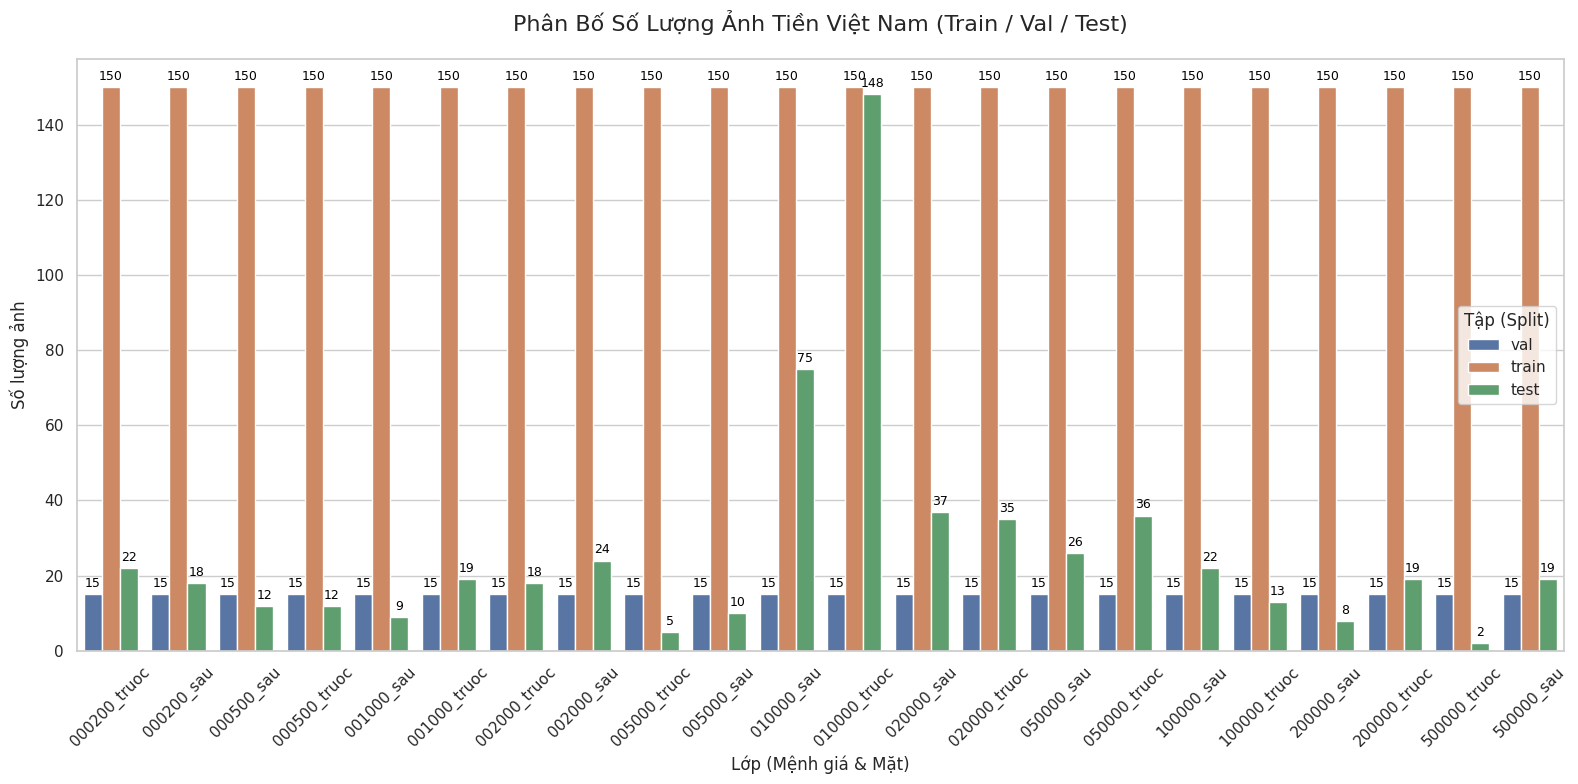

In [ ]:
def check_dataset_balance_all_splits(dataset_dir):
    data = []

    splits = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d)) and not d.startswith('.')]

    for split in splits:
        split_path = os.path.join(dataset_dir, split)

        denominations = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        denominations.sort()

        for denomination in denominations:
            denomi_path = os.path.join(split_path, denomination)

            sides = [s for s in os.listdir(denomi_path) if os.path.isdir(os.path.join(denomi_path, s))]

            for side in sides:
                side_path = os.path.join(denomi_path, side)

                valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
                num_images = len([
                    f for f in os.listdir(side_path)
                    if os.path.isfile(os.path.join(side_path, f)) and f.lower().endswith(valid_extensions)
                ])

                data.append({
                    'Tập (Split)': split,
                    'Mệnh giá': denomination,
                    'Mặt': side,
                    'Lớp (Class)': f"{denomination}_{side}",
                    'Số lượng': num_images
                })

    if not data:
        print("Không tìm thấy dữ liệu. Hãy kiểm tra lại cấu trúc thư mục!")
        return

    df = pd.DataFrame(data)

    print("="*65)
    print("BẢNG THỐNG KÊ SỐ LƯỢNG ẢNH THEO TẬP (TRAIN/VAL/TEST)")
    print("="*65)

    pivot_df = df.pivot_table(index=['Lớp (Class)', 'Mệnh giá', 'Mặt'],
                              columns='Tập (Split)',
                              values='Số lượng',
                              fill_value=0).reset_index()

    actual_splits = [col for col in splits if col in pivot_df.columns]

    pivot_df['Tổng cộng'] = pivot_df[actual_splits].sum(axis=1) if actual_splits else 0
    print(pivot_df.to_string(index=False))

    print("\n" + "="*65)
    print("TỔNG QUAN PHÂN BỔ DỮ LIỆU")
    print("="*65)
    for split in actual_splits:
        split_total = df[df['Tập (Split)'] == split]['Số lượng'].sum()
        print(f"Tổng số ảnh tập {split.upper()}: {split_total}")

    print(f"Tổng số ảnh toàn bộ dataset: {df['Số lượng'].sum()}")

    plt.figure(figsize=(16, 8))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(data=df, x='Lớp (Class)', y='Số lượng', hue='Tập (Split)')

    plt.title('Phân Bố Số Lượng Ảnh Tiền Việt Nam (Train / Val / Test)', fontsize=16, pad=20)
    plt.xlabel('Lớp (Mệnh giá & Mặt)', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)
    plt.xticks(rotation=45)

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=9, color='black', xytext=(0, 3),
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()

check_dataset_balance_all_splits(DATASET_PATH)

# Cân bằng dữ liệu

In [ ]:
!pip install albumentations opencv-python

In [ ]:
import cv2
import random
import albumentations as A
import shutil

In [ ]:
def balance_train_data_to_fixed_target(train_dir, target_count=150):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3)
    ])

    denominations = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

    for denomination in denominations:
        deno_path = os.path.join(train_dir, denomination)
        sides = [s for s in os.listdir(deno_path) if os.path.isdir(os.path.join(deno_path, s))]

        for side in sides:
            side_path = os.path.join(deno_path, side)
            valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')

            files = sorted([f for f in os.listdir(side_path) if f.lower().endswith(valid_exts)])
            current_count = len(files)

            if current_count > target_count:
                random.shuffle(files)
                files_to_delete = files[target_count:]
                for f in files_to_delete:
                    os.remove(os.path.join(side_path, f))

            elif current_count < target_count:
                needed = target_count - current_count
                for i in range(needed):
                    random_image_name = random.choice(files)
                    img_path = os.path.join(side_path, random_image_name)

                    image = cv2.imread(img_path)
                    if image is None: continue
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                    augmented = transform(image=image)
                    aug_img = augmented['image']

                    aug_img = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
                    new_filename = f"aug_fixed_{i}_{random_image_name}"
                    cv2.imwrite(os.path.join(side_path, new_filename), aug_img)

    print(f"Done: {target_count} images per class.")

TRAIN_PATH = '/content/drive/MyDrive/UIT_YEAR2/CS231/DoAn/DATASET/train'
balance_train_data_to_fixed_target(TRAIN_PATH, target_count=150)